# Study on the duration (risk) premium

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
example_root = Path(os.path.abspath(""))

## Data loading

In [2]:
eurirs_df = pd.read_csv(example_root / "data" / f"EURIRS_history_2000-01-01_to_2025-12-31.csv")
eurbmk_df = pd.read_csv(example_root / "data" / f"0#EUBMK=_history_2000-01-01_to_2025-12-31.csv")

In [3]:
buckets = dict([(f"{i}M", i / 12.) for i in range(1, 19)] + [(f"{i}Y", i) for i in range(1, 51)])

In [4]:
# Rename the columns for EURIRS Curve
eurirs_map = {}

for col in eurirs_df.columns:
  if col == "Date":
    continue
  
  col_mat = col.split("=")[0][-3:]
  
  try:
    col_ttm  = int(col_mat[:2])
    col_mat = col_mat
  except Exception as e:
    col_mat = col_mat[1:]
  
  eurirs_map[col] = col_mat
  
eurirs_df.rename(columns=eurirs_map, inplace=True)

In [5]:
# Rename the columns for 0#EUBMK= Curve
eurbmk_map = {}

for col in eurbmk_df.columns:
  if col == "Date":
    continue
  
  col_mat = col.split("=")[0][-4:-1]
  
  try:
    col_ttm  = int(col_mat[:2])
    col_mat = col_mat
  except Exception as e:
    col_mat = col_mat[1:]
  
  eurbmk_map[col] = col_mat
  
eurbmk_df.rename(columns=eurbmk_map, inplace=True)

In [6]:
eurirs_color = "royalblue"
eurbmk_color = "indianred"

## Risk premiums for 1Y holding period

Consider the 1Y spot rate on a given yield curve. If a zero-coupon bond with said 1Y to maturity could be purchased, the return of holding it for a year is known in advance (the YTM). Fama (1984b) defines the premium as 

$$
  \Pi^{(t)}_\tau = H^{(t)}_\tau - H^{(t)}_1,
$$

where $H^{(t)}_i$ is the observed (continuously) compunding single period rate of return for maturity $i$ over the interval $t - 1$ to $t$.

The holding period return is defined as (assuming no coupons)

$$
  H^{(t)}_\tau = \frac{P^{(t)}_{\tau} - P^{(t-1)}_{\tau + 1}}{P^{(t-1)}_{\tau + 1}} ,
$$

where $P^{(t)}_i$ is the price of a zero-coupon bond with maturity $i$ at time $t$. 

Obviously, the return for bonds with longer than 1Y to maturity is dependent on the development of interest rates in the coming year. Thus, the risk premium needs to be studied statistically.

In [7]:
eurirs_df = eurirs_df[["Date", "1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y", "14Y", "15Y", "19Y", "20Y", "29Y", "30Y"]]
eurbmk_df = eurbmk_df[["Date", "1Y", "2Y", "3Y", "4Y", "5Y", "6Y", "7Y", "8Y", "9Y", "10Y"]]
eurirs_df.index = pd.DatetimeIndex(eurirs_df["Date"])
eurbmk_df.index = pd.DatetimeIndex(eurbmk_df["Date"])
eurirs_df.drop(columns=["Date"], inplace=True)
eurbmk_df.drop(columns=["Date"], inplace=True)

In [8]:
# Find the spot rates shifted by 1Y
for i in range(1, 31):
  try:
    eurirs_df[f"S{i}Y1Y"] = eurirs_df[f"{i}Y"].shift(periods=365, freq='D').astype(np.float64)
  except Exception:
    pass
  
  try:
    eurbmk_df[f"S{i}Y1Y"] = eurbmk_df[f"{i}Y"].shift(periods=365, freq='D').astype(np.float64)
  except Exception:
    pass

In [9]:
# Find the holding period returns
for i in range(2, 31):
  try:
    eurirs_df[f"H{i}Y{i-1}Y"] = (np.exp(-eurirs_df[f"{i - 1}Y"].to_numpy() / 100 * (i - 1)) - np.exp(-eurirs_df[f"S{i}Y1Y"].to_numpy() / 100 * i)) / np.exp(-eurirs_df[f"S{i}Y1Y"].to_numpy() / 100 * i)
  except Exception:
    pass
  
  try:
    eurbmk_df[f"H{i}Y{i-1}Y"] = (np.exp(-eurbmk_df[f"{i - 1}Y"].to_numpy() / 100 * (i - 1)) - np.exp(-eurbmk_df[f"S{i}Y1Y"].to_numpy() / 100 * i)) / np.exp(-eurbmk_df[f"S{i}Y1Y"].to_numpy() / 100 * i)
  except Exception:
    pass
  
eurirs_df[f"H1Y0Y"] = (1. - np.exp(-eurirs_df[f"S1Y1Y"].to_numpy() / 100 * 1.)) / np.exp(-eurirs_df[f"S1Y1Y"].to_numpy() / 100 * 1.)
eurbmk_df[f"H1Y0Y"] = (1. - np.exp(-eurbmk_df[f"S1Y1Y"].to_numpy() / 100 * 1.)) / np.exp(-eurbmk_df[f"S1Y1Y"].to_numpy() / 100 * 1.)

In [10]:
(np.exp(-eurirs_df[f"29Y"].to_numpy() / 100 * (10 - 1)) - np.exp(-eurirs_df[f"S30Y1Y"].to_numpy() / 100 * 10)) / np.exp(-eurirs_df[f"S30Y1Y"].to_numpy() / 100 * 10)

array([        nan,         nan,         nan, ...,         nan,
       -0.07426013, -0.07411941], shape=(6790,))

In [11]:
eurirs_df = eurirs_df.dropna()
eurbmk_df = eurbmk_df.dropna()

In [12]:
eurirs_df.head()

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,...,H5Y4Y,H6Y5Y,H7Y6Y,H8Y7Y,H9Y8Y,H10Y9Y,H15Y14Y,H20Y19Y,H30Y29Y,H1Y0Y
Date,,,,,,,,,,,,,,,,,,,,,
2002-07-11,3.6950,4.0400,4.300,4.505,4.6650,4.785,4.910,4.980,5.055,5.130,...,0.068013,0.073367,0.079934,0.084913,0.092288,0.097517,0.134197,0.174098,0.265541,0.044721
2002-07-12,3.6875,4.0155,4.285,4.473,4.6325,4.765,4.875,4.965,5.038,5.093,...,0.067565,0.072696,0.079643,0.085575,0.091191,0.096453,0.135502,0.177773,0.265067,0.044617
2002-07-16,3.6900,4.0300,4.300,4.505,4.6700,4.785,4.910,4.980,5.055,5.130,...,0.066519,0.071265,0.076613,0.080669,0.087335,0.091934,0.124878,0.164451,0.252197,0.044721
2002-07-17,3.6825,4.0150,4.290,4.500,4.6650,4.775,4.900,4.975,5.050,5.120,...,0.065559,0.068547,0.074360,0.077884,0.083422,0.087085,0.126933,0.158846,0.250289,0.044617
2002-07-18,3.7000,4.0350,4.305,4.510,4.6700,4.780,4.905,4.980,5.050,5.125,...,0.064122,0.068312,0.074677,0.078283,0.083916,0.088826,0.119800,0.154451,0.236457,0.044303


In [13]:
eurbmk_df.head()

,1Y,2Y,3Y,4Y,5Y,6Y,7Y,8Y,9Y,10Y,...,H2Y1Y,H3Y2Y,H4Y3Y,H5Y4Y,H6Y5Y,H7Y6Y,H8Y7Y,H9Y8Y,H10Y9Y,H1Y0Y
Date,,,,,,,,,,,,,,,,,,,,,
2003-06-10,1.818,1.8805,2.2140,2.4975,2.567,2.853,3.067,3.250,3.4630,3.5250,...,0.066690,0.095795,0.122322,0.148521,0.177402,0.194760,0.211271,0.218865,0.220097,0.037486
2003-06-11,1.822,1.8920,2.2110,2.4855,2.572,2.848,3.054,3.233,3.4565,3.5200,...,0.066647,0.095346,0.122019,0.149762,0.178238,0.196122,0.214169,0.220084,0.220566,0.037486
2003-06-12,1.830,1.9085,2.2335,2.4890,2.580,2.853,3.061,3.232,3.3955,3.5155,...,0.065901,0.093835,0.119873,0.146960,0.174380,0.192504,0.209842,0.216126,0.222998,0.037174
2003-06-13,1.818,1.8725,2.1940,2.4590,2.550,2.818,3.021,3.192,3.4005,3.4620,...,0.064856,0.093179,0.118916,0.145298,0.174168,0.189710,0.207570,0.214491,0.216837,0.037071
2003-06-17,1.876,1.9875,2.3025,2.6220,2.741,3.004,3.197,3.353,3.5370,3.5910,...,0.063707,0.089752,0.114053,0.136093,0.158690,0.175067,0.191353,0.197169,0.200238,0.036863


### Mean risk premium

#### Full dataset

In [14]:
eurirs_maturity = []
eurbmk_maturity = []
eurirs_premium  = []
eurbmk_premium  = []

for i in range(2, 31):
  print(f"Risk premium for maturity {i}Y:")
  
  try:
    eurirs_mean_risk_prem = np.mean(eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - eurirs_df[f"H1Y0Y"].to_numpy())
    eurirs_std_risk_prem = np.std(eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - eurirs_df[f"H1Y0Y"].to_numpy())
    print(f"EURIRS mean: {eurirs_mean_risk_prem:.3f}")
    print(f"EURIRS std: {eurirs_std_risk_prem:.3f}")
    eurirs_premium.append(eurirs_mean_risk_prem)
    eurirs_maturity.append(i)
  except Exception:
    pass

  try:
    eurbmk_mean_risk_prem = np.mean(eurbmk_df[f"H{i}Y{i-1}Y"].to_numpy() - eurbmk_df[f"H1Y0Y"].to_numpy())
    print(f"EURBMK: {eurbmk_mean_risk_prem:.3f}")
    eurbmk_premium.append(eurbmk_mean_risk_prem)
    eurbmk_maturity.append(i)
  except Exception:
    pass


Risk premium for maturity 2Y:
EURIRS mean: 0.002
EURIRS std: 0.011
EURBMK: 0.001
Risk premium for maturity 3Y:
EURIRS mean: 0.006
EURIRS std: 0.021
EURBMK: 0.004
Risk premium for maturity 4Y:
EURIRS mean: 0.010
EURIRS std: 0.029
EURBMK: 0.009
Risk premium for maturity 5Y:
EURIRS mean: 0.014
EURIRS std: 0.038
EURBMK: 0.012
Risk premium for maturity 6Y:
EURIRS mean: 0.017
EURIRS std: 0.045
EURBMK: 0.016
Risk premium for maturity 7Y:
EURIRS mean: 0.021
EURIRS std: 0.053
EURBMK: 0.019
Risk premium for maturity 8Y:
EURIRS mean: 0.024
EURIRS std: 0.060
EURBMK: 0.022
Risk premium for maturity 9Y:
EURIRS mean: 0.026
EURIRS std: 0.067
EURBMK: 0.025
Risk premium for maturity 10Y:
EURIRS mean: 0.029
EURIRS std: 0.074
EURBMK: 0.027
Risk premium for maturity 11Y:
Risk premium for maturity 12Y:
Risk premium for maturity 13Y:
Risk premium for maturity 14Y:
Risk premium for maturity 15Y:
EURIRS mean: 0.039
EURIRS std: 0.109
Risk premium for maturity 16Y:
Risk premium for maturity 17Y:
Risk premium for

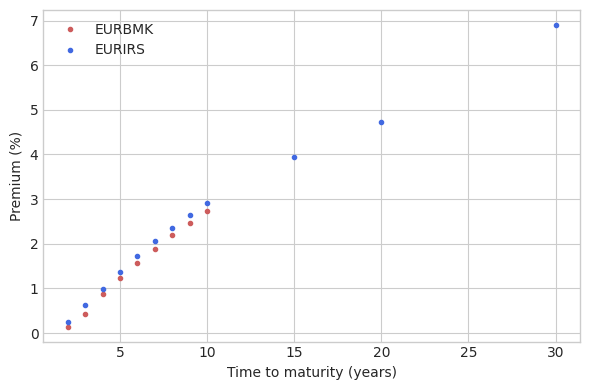

In [15]:
fig = plt.figure(figsize=(6, 4))

plt.plot(eurbmk_maturity, np.array(eurbmk_premium) * 100, color=eurbmk_color, linestyle="None", marker='.', label="EURBMK")
plt.plot(eurirs_maturity, np.array(eurirs_premium) * 100, color=eurirs_color, linestyle="None", marker='.', label="EURIRS")

plt.legend()
plt.xlabel("Time to maturity (years)")
plt.ylabel("Premium (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "duration_premium_2000_2025.png")
fig.savefig(example_root / "figures" / "duration_premium_2000_2025.pdf")

plt.show()

#### Financial crisis (2007-2009)

In [16]:
tmp_eurirs_df = eurirs_df[(eurirs_df.index >= "2007-01-01") & (eurirs_df.index <= "2009-12-31")]
tmp_eurbmk_df = eurbmk_df[(eurbmk_df.index >= "2007-01-01") & (eurbmk_df.index <= "2009-12-31")]

eurirs_maturity = []
eurbmk_maturity = []
eurirs_premium  = []
eurbmk_premium  = []

for i in range(2, 31):
  print(f"Risk premium for maturity {i}Y:")
  
  try:
    eurirs_mean_risk_prem = np.mean(tmp_eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurirs_df[f"H1Y0Y"].to_numpy())
    eurirs_std_risk_prem = np.std(tmp_eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurirs_df[f"H1Y0Y"].to_numpy())
    print(f"EURIRS mean: {eurirs_mean_risk_prem:.3f}")
    print(f"EURIRS std: {eurirs_std_risk_prem:.3f}")
    eurirs_premium.append(eurirs_mean_risk_prem)
    eurirs_maturity.append(i)
  except Exception:
    pass

  try:
    eurbmk_mean_risk_prem = np.mean(tmp_eurbmk_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurbmk_df[f"H1Y0Y"].to_numpy())
    print(f"EURBMK: {eurbmk_mean_risk_prem:.3f}")
    eurbmk_premium.append(eurbmk_mean_risk_prem)
    eurbmk_maturity.append(i)
  except Exception:
    pass

Risk premium for maturity 2Y:
EURIRS mean: 0.006
EURIRS std: 0.016
EURBMK: 0.008
Risk premium for maturity 3Y:
EURIRS mean: 0.013
EURIRS std: 0.029
EURBMK: 0.017
Risk premium for maturity 4Y:
EURIRS mean: 0.016
EURIRS std: 0.037
EURBMK: 0.023
Risk premium for maturity 5Y:
EURIRS mean: 0.018
EURIRS std: 0.044
EURBMK: 0.021
Risk premium for maturity 6Y:
EURIRS mean: 0.020
EURIRS std: 0.049
EURBMK: 0.029
Risk premium for maturity 7Y:
EURIRS mean: 0.021
EURIRS std: 0.054
EURBMK: 0.023
Risk premium for maturity 8Y:
EURIRS mean: 0.022
EURIRS std: 0.058
EURBMK: 0.026
Risk premium for maturity 9Y:
EURIRS mean: 0.023
EURIRS std: 0.063
EURBMK: 0.023
Risk premium for maturity 10Y:
EURIRS mean: 0.023
EURIRS std: 0.067
EURBMK: 0.024
Risk premium for maturity 11Y:
Risk premium for maturity 12Y:
Risk premium for maturity 13Y:
Risk premium for maturity 14Y:
Risk premium for maturity 15Y:
EURIRS mean: 0.022
EURIRS std: 0.089
Risk premium for maturity 16Y:
Risk premium for maturity 17Y:
Risk premium for

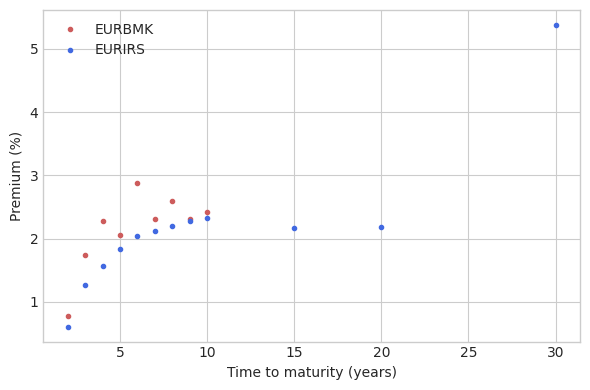

In [17]:
fig = plt.figure(figsize=(6, 4))

plt.plot(eurbmk_maturity, np.array(eurbmk_premium) * 100, color=eurbmk_color, linestyle="None", marker='.', label="EURBMK")
plt.plot(eurirs_maturity, np.array(eurirs_premium) * 100, color=eurirs_color, linestyle="None", marker='.', label="EURIRS")

plt.legend()
plt.xlabel("Time to maturity (years)")
plt.ylabel("Premium (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "duration_premium_2007_2009.png")
fig.savefig(example_root / "figures" / "duration_premium_2007_2009.pdf")

plt.show()

#### Euro area crisis (2010-2014)

In [18]:
tmp_eurirs_df = eurirs_df[(eurirs_df.index >= "2010-01-01") & (eurirs_df.index <= "2014-12-31")]
tmp_eurbmk_df = eurbmk_df[(eurbmk_df.index >= "2010-01-01") & (eurbmk_df.index <= "2014-12-31")]

eurirs_maturity = []
eurbmk_maturity = []
eurirs_premium  = []
eurbmk_premium  = []

for i in range(2, 31):
  print(f"Risk premium for maturity {i}Y:")
  
  try:
    eurirs_mean_risk_prem = np.mean(tmp_eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurirs_df[f"H1Y0Y"].to_numpy())
    eurirs_std_risk_prem = np.std(tmp_eurirs_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurirs_df[f"H1Y0Y"].to_numpy())
    print(f"EURIRS mean: {eurirs_mean_risk_prem:.3f}")
    print(f"EURIRS std: {eurirs_std_risk_prem:.3f}")
    eurirs_premium.append(eurirs_mean_risk_prem)
    eurirs_maturity.append(i)
  except Exception:
    pass

  try:
    eurbmk_mean_risk_prem = np.mean(tmp_eurbmk_df[f"H{i}Y{i-1}Y"].to_numpy() - tmp_eurbmk_df[f"H1Y0Y"].to_numpy())
    print(f"EURBMK: {eurbmk_mean_risk_prem:.3f}")
    eurbmk_premium.append(eurbmk_mean_risk_prem)
    eurbmk_maturity.append(i)
  except Exception:
    pass

Risk premium for maturity 2Y:
EURIRS mean: 0.006
EURIRS std: 0.005
EURBMK: 0.006
Risk premium for maturity 3Y:
EURIRS mean: 0.016
EURIRS std: 0.012
EURBMK: 0.014
Risk premium for maturity 4Y:
EURIRS mean: 0.025
EURIRS std: 0.019
EURBMK: 0.027
Risk premium for maturity 5Y:
EURIRS mean: 0.035
EURIRS std: 0.026
EURBMK: 0.037
Risk premium for maturity 6Y:
EURIRS mean: 0.043
EURIRS std: 0.033
EURBMK: 0.048
Risk premium for maturity 7Y:
EURIRS mean: 0.050
EURIRS std: 0.039
EURBMK: 0.056
Risk premium for maturity 8Y:
EURIRS mean: 0.057
EURIRS std: 0.044
EURBMK: 0.064
Risk premium for maturity 9Y:
EURIRS mean: 0.063
EURIRS std: 0.050
EURBMK: 0.069
Risk premium for maturity 10Y:
EURIRS mean: 0.068
EURIRS std: 0.056
EURBMK: 0.073
Risk premium for maturity 11Y:
Risk premium for maturity 12Y:
Risk premium for maturity 13Y:
Risk premium for maturity 14Y:
Risk premium for maturity 15Y:
EURIRS mean: 0.091
EURIRS std: 0.090
Risk premium for maturity 16Y:
Risk premium for maturity 17Y:
Risk premium for

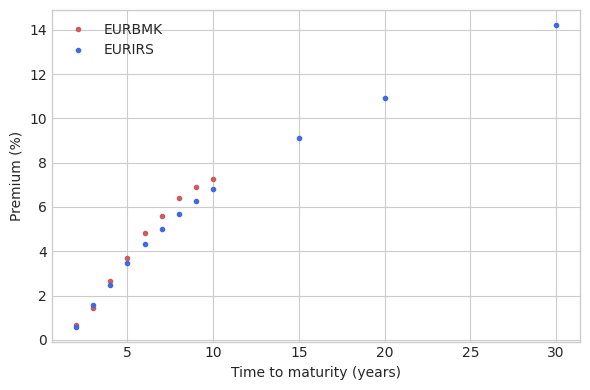

In [19]:
fig = plt.figure(figsize=(6, 4))

plt.plot(eurbmk_maturity, np.array(eurbmk_premium) * 100, color=eurbmk_color, linestyle="None", marker='.', label="EURBMK")
plt.plot(eurirs_maturity, np.array(eurirs_premium) * 100, color=eurirs_color, linestyle="None", marker='.', label="EURIRS")

plt.legend()
plt.xlabel("Time to maturity (years)")
plt.ylabel("Premium (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "duration_premium_2010_2014.png")
fig.savefig(example_root / "figures" / "duration_premium_2010_2014.pdf")

plt.show()

## Hotelling $t^2$ test